In [2]:
!pip install pandas

  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl (12.4 MB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
  Attempting uninstall: numpy
   ---------------------------------------- 0/3 [tzdata]
    Found existing installation: numpy 2.2.6
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
    Uninstalling numpy-2.2.6:
   ------------- -------------------------- 1/3 [nu

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

In [7]:
DATASET_PATH = r"C:\Users\bhanu\Downloads\StructCompose\data\raw\CADB"

print(os.listdir(DATASET_PATH))

['composition_attributes.json', 'composition_elements.json', 'composition_scores.json', 'images', 'scene_categories.json', 'split.json', 'visualize_cadb_annotation.py']


In [8]:
for root, dirs, files in os.walk(DATASET_PATH):
    print(f"\nPATH: {root}")
    print("Folders:", dirs[:5])
    print("Files:", files[:5])


PATH: C:\Users\bhanu\Downloads\StructCompose\data\raw\CADB
Folders: ['images']
Files: ['composition_attributes.json', 'composition_elements.json', 'composition_scores.json', 'scene_categories.json', 'split.json']

PATH: C:\Users\bhanu\Downloads\StructCompose\data\raw\CADB\images
Folders: []
Files: ['1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg']


In [9]:
attribute_file = r"C:\Users\bhanu\Downloads\StructCompose\data\raw\CADB\composition_attributes.json"

with open(attribute_file, "r") as f:
    attributes = json.load(f)

print(type(attributes))
print(len(attributes))

<class 'dict'>
9497


In [10]:
first_key = list(attributes.keys())[0]

print("Image Name:", first_key)
print(attributes[first_key])

Image Name: 10003.jpg
{'Light': 0.4, 'Symmetry': 0.0, 'Object': -0.4, 'score': 0.65, 'RuleOfThirds': 0.4, 'Repetition': 0.0, 'BalacingElements': 0.0, 'ColorHarmony': 0.8, 'MotionBlur': 0.0, 'VividColor': 0.4, 'DoF': 0.0, 'Content': 0.6}


In [11]:
rows = []

for image_name, values in attributes.items():

    row = {
        "image_name": image_name
    }

    for k, v in values.items():
        row[k] = v

    rows.append(row)

df = pd.DataFrame(rows)

print(df.head())

  image_name  Light  Symmetry  Object  score  RuleOfThirds  Repetition  \
0  10003.jpg    0.4       0.0    -0.4  0.650           0.4         0.0   
1  10007.jpg    0.2       0.0     0.4  0.500           0.0         0.0   
2  10008.jpg    0.0       0.2     0.2  0.400          -0.4         0.0   
3   1001.jpg   -0.2       0.0     0.8  0.438          -0.2         0.0   
4  10010.jpg    0.2       0.0    -0.4  0.550          -0.4         0.2   

   BalacingElements  ColorHarmony  MotionBlur  VividColor  DoF  Content  
0               0.0           0.8         0.0         0.4  0.0      0.6  
1               0.0           0.2        -0.2        -0.2 -0.2      0.2  
2               0.0           0.2         0.0        -0.4  0.2      0.4  
3               0.2           0.0         0.0         0.0  0.0      0.4  
4               0.0           0.4         0.0         0.4  0.2      1.0  


In [12]:
print(df.shape)

print(df.columns)

print(df.describe())

(9497, 13)
Index(['image_name', 'Light', 'Symmetry', 'Object', 'score', 'RuleOfThirds',
       'Repetition', 'BalacingElements', 'ColorHarmony', 'MotionBlur',
       'VividColor', 'DoF', 'Content'],
      dtype='str')
             Light     Symmetry       Object        score  RuleOfThirds  \
count  9497.000000  9497.000000  9497.000000  9497.000000   9497.000000   
mean      0.011416     0.023994     0.053199     0.513447      0.001203   
std       0.350392     0.085518     0.506045     0.184266      0.232570   
min      -1.000000     0.000000    -1.000000     0.000000     -1.000000   
25%      -0.200000     0.000000    -0.400000     0.400000     -0.200000   
50%       0.000000     0.000000     0.000000     0.500000      0.000000   
75%       0.200000     0.000000     0.400000     0.650000      0.200000   
max       1.000000     1.000000     1.000000     1.000000      1.000000   

        Repetition  BalacingElements  ColorHarmony   MotionBlur   VividColor  \
count  9497.000000       9

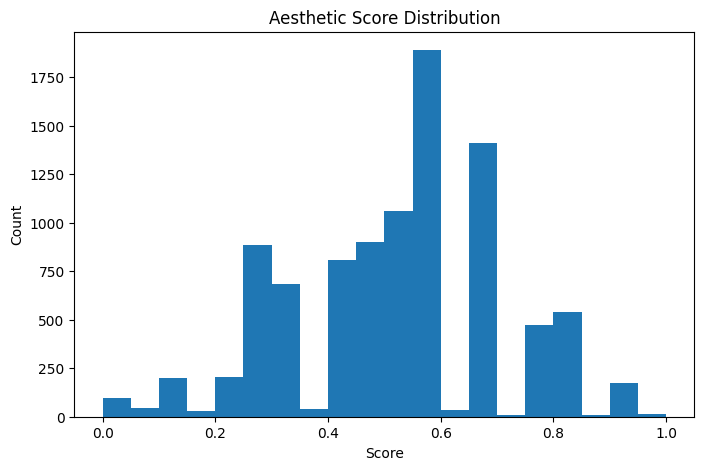

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["score"], bins=20)

plt.title("Aesthetic Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

plt.show()

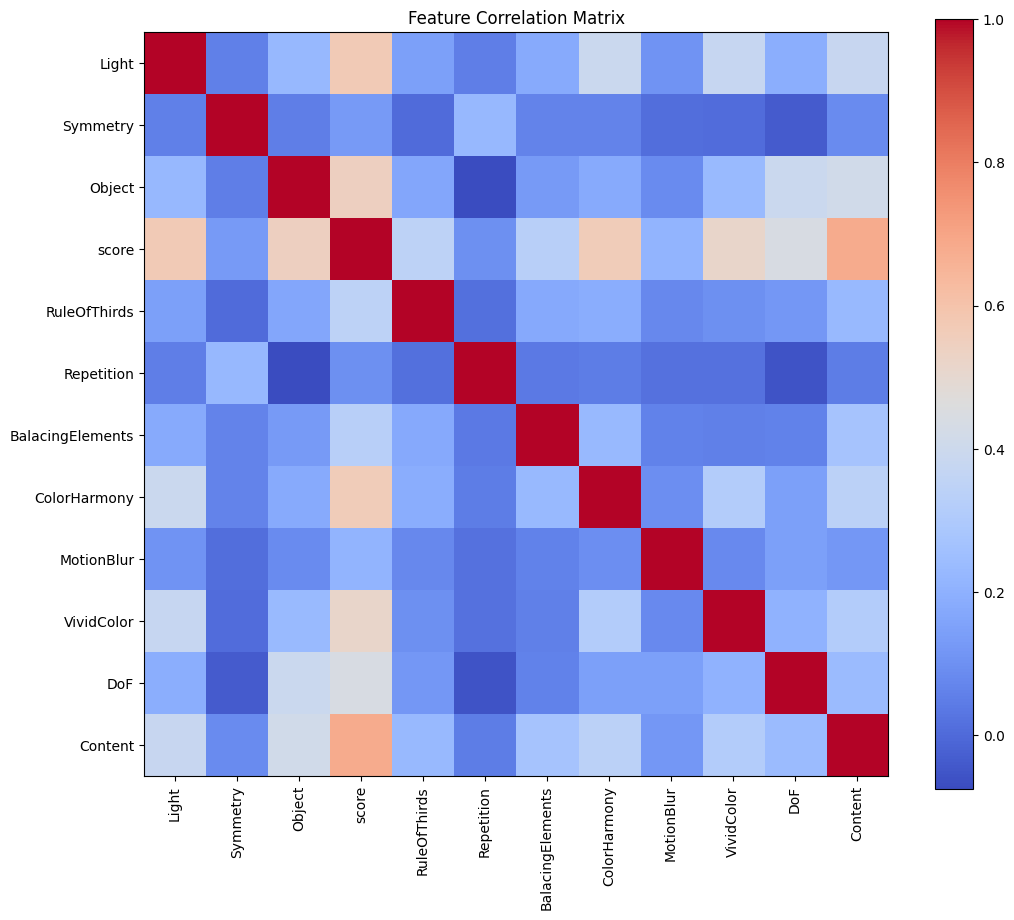

In [14]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,10))

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Matrix")

plt.show()

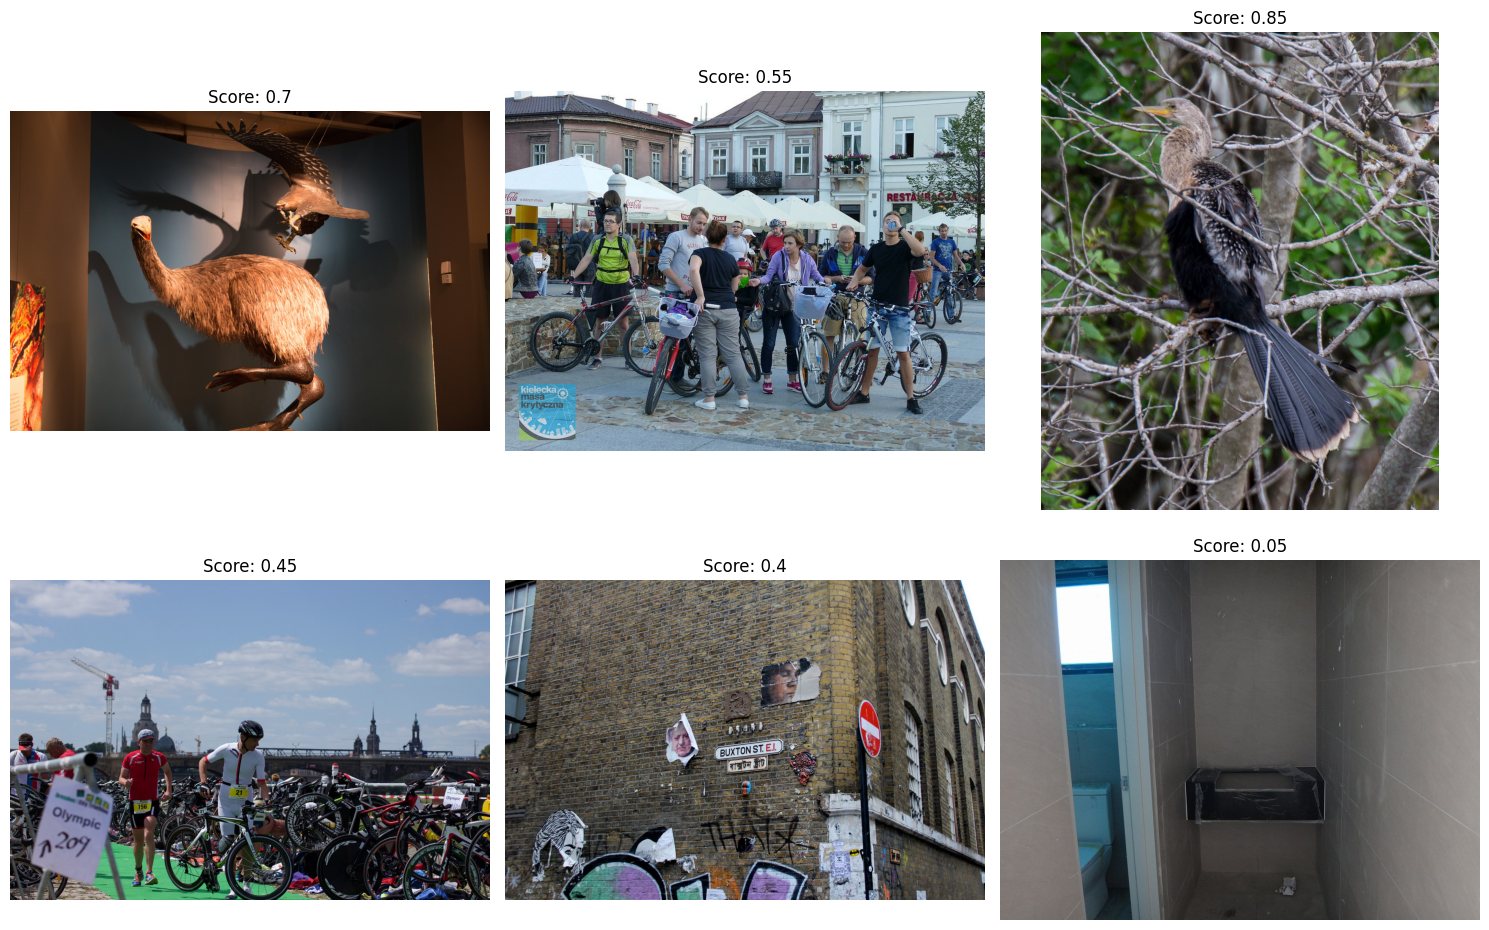

In [15]:
IMAGE_DIR = r"C:\Users\bhanu\Downloads\StructCompose\data\raw\CADB\images"
sample_images = df["image_name"].sample(6).values

plt.figure(figsize=(15,10))

for i, img_name in enumerate(sample_images):

    path = os.path.join(IMAGE_DIR, img_name)

    img = cv2.imread(path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    score = df[df["image_name"] == img_name]["score"].values[0]

    plt.title(f"Score: {score}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
save_path = r"C:\Users\bhanu\Downloads\StructCompose\data\metadata\master_metadata.csv"

df.to_csv(save_path, index=False)

print("Saved metadata CSV")

Saved metadata CSV
